# JXPaint Tutorial 3 — Speed, and varying cosmology with no interpolator rebuild

Two things that make JXPaint useful for inference:
1. it paints a full catalogue in ~0.2 s on the GPU (the production Julia XGPaint
   painter takes **108 s/catalogue**), and
2. **varying cosmology costs almost nothing** — the beam-convolved shape table is
   cosmology-independent, so it is built once and reused; only the geometry
   $\theta_{500}(M,z)$ is recomputed (~6 ms).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.join("..", "src"))   # run from tutorials/
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import jax
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
import pandas as pd
from jxpaint.profiles.shape_table import load_beamed_table
from jxpaint.painting.gpu_native import paint_catalogue_gpu_native, compute_geometry
from jxpaint.cosmology import FlatLCDM
from jxpaint import constants as C

CAT = "/rds/rds-lxu/tsz_project/tsz_catalogue_benchmark/catalogue_bench_snr_0.csv"
st = load_beamed_table()
df = pd.read_csv(CAT)
z, M, lon, lat, y0 = (df.z.values, df.M.values, df.lon.values,
                      df.lat.values, df.y0_true.values)
XGPAINT_SECONDS = 108.07   # production paint_a10_y0true_2d_mpi.jl, self-reported

## 1. Speed vs XGPaint

In [3]:
paint_catalogue_gpu_native(z, M, lon, lat, y0, st)         # warm up (compile)
ts = []
for _ in range(5):
    t0 = time.time(); m = paint_catalogue_gpu_native(z, M, lon, lat, y0, st)
    ts.append(time.time()-t0)
t = float(np.min(ts))
print(f"JXPaint (GPU):  {t:.3f} s / catalogue")
print(f"XGPaint (CPU):  {XGPAINT_SECONDS:.1f} s / catalogue")
print(f"speedup:        {XGPAINT_SECONDS/t:.0f}x   (bit-for-bit identical map)")

JXPaint (GPU):  0.180 s / catalogue
XGPaint (CPU):  108.1 s / catalogue
speedup:        600x   (bit-for-bit identical map)


## 2. Varying cosmology — the interpolator is **never rebuilt**

In XGPaint, changing cosmology means rebuilding the high-precision
(8192×8192, FFTLog-beamed) interpolator — expensive. In JXPaint the table is
cosmology-independent: we reuse the same `st` object for every cosmology and only
recompute the geometry. Below we paint the same catalogue under a grid of
cosmologies.

In [4]:
cosmos = [FlatLCDM(h=h, Omega_m=Om) for h in (0.64, 0.6766, 0.70, 0.74)
          for Om in (0.27, 0.31, 0.35)]
paint_catalogue_gpu_native(z, M, lon, lat, y0, st, cosmo=cosmos[0])   # compile once

rows = []
for cz in cosmos:
    tg = []
    for _ in range(5):
        t0 = time.time()
        _, th500, _, _ = compute_geometry(z, M, lon, lat, y0, cz, C.B_BIAS)
        th500.block_until_ready(); tg.append(time.time()-t0)
    t0 = time.time(); mm = paint_catalogue_gpu_native(z, M, lon, lat, y0, st, cosmo=cz)
    tp = time.time()-t0
    rows.append((cz.h, cz.Omega_m, min(tg)*1e3, tp, mm.sum()))
res = pd.DataFrame(rows, columns=["h", "Omega_m", "geom_ms", "paint_s", "map_sum"])
print("interpolator rebuilds:", 0, " (same table object reused for all",
      len(cosmos), "cosmologies)")
res

interpolator rebuilds: 0  (same table object reused for all 12 cosmologies)


,h,Omega_m,geom_ms,paint_s,map_sum
0,0.6400,0.27,7.988214,0.178690,2.350211
1,0.6400,0.31,7.965565,0.182272,2.334308
2,0.6400,0.35,7.283926,0.181755,2.320134
3,0.6766,0.27,7.457495,0.181650,2.438078
4,0.6766,0.31,6.928682,0.182011,2.421579
5,0.6766,0.35,6.901503,0.182076,2.406874
6,0.7000,0.27,7.328272,0.182506,2.493402
7,0.7000,0.31,7.457733,0.181871,2.476528
8,0.7000,0.35,7.385015,0.183366,2.461488
9,0.7400,0.27,7.541656,0.181179,2.586522


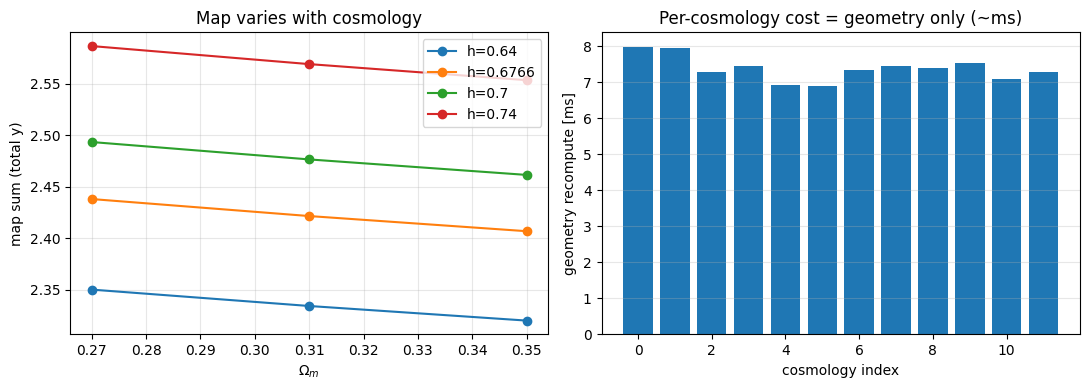

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for h in sorted(res.h.unique()):
    sub = res[res.h == h]
    ax[0].plot(sub.Omega_m, sub.map_sum, "o-", label=f"h={h}")
ax[0].set_xlabel(r"$\Omega_m$"); ax[0].set_ylabel("map sum (total y)")
ax[0].set_title("Map varies with cosmology"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].bar(range(len(res)), res.geom_ms)
ax[1].set_xlabel("cosmology index"); ax[1].set_ylabel("geometry recompute [ms]")
ax[1].set_title("Per-cosmology cost = geometry only (~ms)"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

**Takeaway:** the beam-convolved interpolator is built/loaded **once** and reused
for every cosmology (0 rebuilds); the only cosmology-dependent work is the
vectorised geometry at ~6 ms/cosmology — negligible. This is what makes JXPaint
practical for cosmology inference where the painter is called thousands of times.